<a href="https://colab.research.google.com/github/anhhongdangcode-pixel/Python-for-data-analysis/blob/master/fomo_pipeline_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FOMO Detection — Data Pipeline & EDA
**Pipeline:** Raw CSV → Enriched Trades → Parquet → EDA

**Flow:**
1. Setup & Clone Repo
2. Data Pipeline (Loader + Builder)
3. Lưu `enriched_trades.parquet`
4. EDA — Khám phá mối quan hệ giữa features và `fomo_prob`

## 1. Setup & Clone Repo

In [1]:
# Clone repo về Colab — thay URL placeholder bằng link repo thật
!git clone https://github.com/anhhongdangcode-pixel/Python-for-data-analysis.git

# Cài thư viện cần thiết
!pip install pyarrow fastparquet --quiet   # để đọc/ghi Parquet
!pip install xgboost optuna --quiet        # để train XGBoost + Optuna tuning


Cloning into 'Python-for-data-analysis'...
remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 17 (delta 0), reused 5 (delta 0), pack-reused 12 (from 1)
Receiving objects: 100% (17/17), 51.74 MiB | 11.10 MiB/s, done.
Updating files: 100% (11/11), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 38.5 MB/s eta 0:00:00


## 2. Cấu hình đường dẫn

In [2]:
import os

# ── Đường dẫn gốc sau khi clone ───────────────────────────────────────────
if os.path.exists('/content'):
    REPO_DIR = '/content/Python-for-data-analysis'
else:
    REPO_DIR = '.'

INPUT_DIR  = os.path.join(REPO_DIR, 'input')
OUTPUT_DIR = os.path.join(REPO_DIR, 'output')
MODEL_DIR  = os.path.join(REPO_DIR, 'model')

TRANSACTIONS_FILE  = os.path.join(INPUT_DIR, 'transactions.csv')
CUSTOMERS_FILE     = os.path.join(INPUT_DIR, 'customer_information.csv')
CLOSE_PRICES_FILE  = os.path.join(INPUT_DIR, 'close_prices.csv')
ASSETS_FILE        = os.path.join(INPUT_DIR, 'asset_information.csv')

SNORKEL_LABELS_FILE     = os.path.join(OUTPUT_DIR, 'snorkel_labels.csv')
ENRICHED_TRADES_PARQUET = os.path.join(OUTPUT_DIR, 'enriched_trades.parquet')
FEATURES_FILE           = os.path.join(OUTPUT_DIR, 'fomo_features.csv')
LF_INPUT_FILE           = os.path.join(OUTPUT_DIR, 'lf_input.csv')

XGBOOST_MODEL_FILE = os.path.join(MODEL_DIR, 'xgboost_fomo.ubj')
OPTUNA_PARAMS_FILE = os.path.join(MODEL_DIR, 'optuna_best_params.json')
RUN_METADATA_FILE  = os.path.join(MODEL_DIR, 'run_metadata.json')

print('Paths configured.')
print(f'  Input:  {INPUT_DIR}')
print(f'  Output: {OUTPUT_DIR}')
print(f'  Model:  {MODEL_DIR}')


Paths configured.
  Input:  /content/Python-for-data-analysis/input
  Output: /content/Python-for-data-analysis/output


## 3. Imports

In [20]:
import json
import datetime
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

import xgboost as xgb
import optuna
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    log_loss, roc_auc_score
)
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("Imports OK.")


Imports OK.


## 4. Data Loader
Tích hợp từ `data_loader.py`.

**Thay đổi chính so với file gốc:**
- Bỏ hoàn toàn logic train/val split
- Chỉ giữ **Mass + Premium** (loại bỏ Professional, Legal Entity, Inactive)
- Output: **một DataFrame duy nhất** `enriched_trades`

In [4]:
# ── Encoding maps ─────────────────────────────────────────────────────────
_RISK_LEVEL_MAP = {
    "Conservative":           1.0,
    "Predicted_Conservative": 1.5,
    "Income":                 2.0,
    "Predicted_Income":       2.5,
    "Balanced":               3.0,
    "Predicted_Balanced":     3.5,
    "Aggressive":             4.0,
    "Predicted_Aggressive":   4.5,
    "Not_Available":          None,
}

_CAPACITY_ORDINAL_MAP = {
    "CAP_LT30K":             1, "Predicted_CAP_LT30K":     1,
    "CAP_30K_80K":           2, "Predicted_CAP_30K_80K":   2,
    "CAP_80K_300K":          3, "Predicted_CAP_80K_300K":  3,
    "CAP_GT300K":            4, "Predicted_CAP_GT300K":    4,
    "Not_Available":         None,
}

_CAPACITY_VALUE_MAP = {
    "CAP_LT30K":             15_000,  "Predicted_CAP_LT30K":    15_000,
    "CAP_30K_80K":           55_000,  "Predicted_CAP_30K_80K":  55_000,
    "CAP_80K_300K":          190_000, "Predicted_CAP_80K_300K": 190_000,
    "CAP_GT300K":            400_000, "Predicted_CAP_GT300K":   400_000,
    "Not_Available":         None,
}

PERIOD_START = "2020-07-01"
PERIOD_END   = "2022-11-30"


def _load_transactions(file: str) -> pd.DataFrame:
    transactions = pd.read_csv(file, parse_dates=["timestamp"])
    transactions["timestamp"] = pd.to_datetime(transactions["timestamp"])

    # Filter time period — bỏ COVID period và data artifact
    before = len(transactions)
    transactions = transactions[
        (transactions["timestamp"] >= PERIOD_START) &
        (transactions["timestamp"] <= PERIOD_END)
    ]
    print(f"[filter period] {before:,} → {len(transactions):,} rows "          f"({before - len(transactions):,} dropped)")

    # Data quality guard
    bad = (transactions["totalValue"] <= 0) | (transactions["units"] <= 0)
    if bad.sum() > 0:
        print(f"[WARNING] Dropping {bad.sum()} rows với totalValue/units <= 0")
        transactions = transactions[~bad]

    transactions["price"] = transactions["totalValue"] / transactions["units"]
    transactions["side"]  = transactions["transactionType"].str.upper()

    invalid = transactions[~transactions["side"].isin(["BUY", "SELL"])]
    if not invalid.empty:
        raise ValueError(f"Invalid transaction types: {invalid['side'].unique().tolist()}")

    trades = transactions[[
        "customerID", "ISIN", "timestamp", "side",
        "price", "units", "channel", "totalValue",
    ]].rename(columns={
        "customerID": "investor_id",
        "ISIN":       "asset_id",
        "units":      "quantity",
    })
    trades["investor_id"] = trades["investor_id"].astype(str)
    return trades


def _load_customers(file: str) -> pd.DataFrame:
    customers = pd.read_csv(file, parse_dates=["timestamp"])
    customers["timestamp"]  = pd.to_datetime(customers["timestamp"])
    customers["customerID"] = customers["customerID"].astype(str)

    # Dedup — lấy record mới nhất per customer
    customers = (
        customers
        .sort_values("timestamp")
        .drop_duplicates(subset=["customerID"], keep="last")
        .reset_index(drop=True)
    )
    assert customers["customerID"].nunique() == len(customers)

    customers["risk_level"]                  = customers["riskLevel"].map(_RISK_LEVEL_MAP)
    customers["investment_capacity_ordinal"] = customers["investmentCapacity"].map(_CAPACITY_ORDINAL_MAP)
    customers["investment_capacity_value"]   = customers["investmentCapacity"].map(_CAPACITY_VALUE_MAP)

    return customers[[
        "customerID", "customerType",
        "risk_level", "investment_capacity_ordinal", "investment_capacity_value",
    ]]


def _filter_by_asset_type(trades: pd.DataFrame, assets_file: str) -> pd.DataFrame:
    assets = pd.read_csv(assets_file)
    assets = (assets.sort_values("timestamp").groupby("ISIN").last().reset_index())
    stock_isins = assets[assets["assetCategory"] == "Stock"]["ISIN"].unique()

    before = len(trades)
    trades = trades[trades["asset_id"].isin(stock_isins)]
    print(f"[filter stock] {before:,} → {len(trades):,} rows "          f"({before - len(trades):,} non-Stock dropped)")
    return trades


def _attach_customer_features(trades: pd.DataFrame, customers: pd.DataFrame) -> pd.DataFrame:
    """
    Chỉ giữ Mass + Premium. Loại bỏ Professional, Legal Entity, Inactive.
    Trả về 1 DataFrame duy nhất (không train/val split).
    """
    valid_customers = customers[customers["customerType"].isin(["Mass", "Premium"])]
    print(f"[customer filter] Giữ Mass+Premium: {len(valid_customers):,} customers "          f"(loại bỏ {len(customers) - len(valid_customers):,} Professional/LegalEntity/Inactive)")

    customer_features = valid_customers[[
        "customerID", "risk_level",
        "investment_capacity_ordinal", "investment_capacity_value",
    ]].drop_duplicates(subset=["customerID"])

    result = trades[trades["investor_id"].isin(valid_customers["customerID"])]
    n_before = len(result)

    result = result.merge(
        customer_features,
        left_on="investor_id", right_on="customerID",
        how="left"
    ).drop(columns=["customerID"])

    assert len(result) == n_before,         f"[BUG] Join inflated trades! {n_before} → {len(result)} rows"

    # position_size_ratio = đo mức độ bet so với capacity
    result["position_size_ratio"] = result["totalValue"] / result["investment_capacity_value"]
    result = result.drop(columns=["investment_capacity_value"])

    print(f"[attach features] {len(result):,} trades | "          f"{result['investor_id'].nunique():,} investors")
    return result


def load_trade_data(transactions_file, customers_file, assets_file) -> pd.DataFrame:
    """
    Full pipeline: raw CSV → trades enriched với customer features.
    Output: 1 DataFrame duy nhất (Mass + Premium investors only).
    """
    trades    = _load_transactions(transactions_file)
    trades    = _filter_by_asset_type(trades, assets_file)
    customers = _load_customers(customers_file)
    trades    = _attach_customer_features(trades, customers)
    return trades


def load_close_prices(file: str, assets_file: str = None) -> pd.DataFrame:
    close_prices = pd.read_csv(file, parse_dates=["timestamp"])
    close_prices = close_prices.rename(columns={
        "ISIN": "asset_id", "closePrice": "market_price",
    })
    close_prices = close_prices[
        (close_prices["timestamp"] >= "2020-01-01") &
        (close_prices["timestamp"] <= PERIOD_END)
    ]
    if assets_file is not None:
        assets = pd.read_csv(assets_file)
        assets = assets.sort_values("timestamp").groupby("ISIN").last().reset_index()
        stock_isins = assets[assets["assetCategory"] == "Stock"]["ISIN"].unique()
        before = len(close_prices)
        close_prices = close_prices[close_prices["asset_id"].isin(stock_isins)]
        print(f"[close prices] filtered to Stock only: {before:,} → {len(close_prices):,} rows")

    return (close_prices[["asset_id", "timestamp", "market_price"]]
            .sort_values(["asset_id", "timestamp"])
            .reset_index(drop=True))

print("Data Loader functions defined.")

Data Loader functions defined.


## 5. Data Builder
Tích hợp từ `data_builder.py`.

Enriches market data với: business-day reindex, returns (1d/5d), volatility (5d/10d), MA (5/20), RSI-14, MACD histogram.

In [5]:
def build_trades(trades: pd.DataFrame) -> pd.DataFrame:
    trades = trades.copy()
    trades["timestamp"] = pd.to_datetime(trades["timestamp"])
    return trades.sort_values(["investor_id", "timestamp"]).reset_index(drop=True)


def _reindex_to_business_days(market: pd.DataFrame) -> pd.DataFrame:
    """
    Reindex về business days (Mon-Fri) và forward fill gap.
    Fix: pct_change(h) sau reindex đo đúng h trading days, không bị inflate bởi weekend gap.
    """
    start = market["timestamp"].min()
    end   = market["timestamp"].max()
    full_bday_idx = pd.date_range(start=start, end=end, freq="B")

    parts = []
    for asset_id, group in market.groupby("asset_id"):
        group = group.set_index("timestamp").reindex(full_bday_idx)
        group["asset_id"]    = asset_id
        group["market_price"] = group["market_price"].ffill()
        group.index.name = "timestamp"
        parts.append(group.reset_index())

    return (pd.concat(parts, ignore_index=True)
            .sort_values(["asset_id", "timestamp"])
            .reset_index(drop=True))


def _add_market_returns(market: pd.DataFrame, horizons=(1, 5)) -> pd.DataFrame:
    for h in horizons:
        market[f"return_{h}d"] = (
            market.groupby("asset_id")["market_price"].pct_change(h)
        )
    return market


def _add_market_volatilities(market: pd.DataFrame, windows=(5, 10)) -> pd.DataFrame:
    for w in windows:
        market[f"volatility_{w}d"] = (
            market.groupby("asset_id")["return_1d"]
            .rolling(w).std()
            .reset_index(level=0, drop=True)
        )
    return market


def _add_moving_averages(market: pd.DataFrame, windows=(5, 20)) -> pd.DataFrame:
    for w in windows:
        market[f"ma_{w}d"] = (
            market.groupby("asset_id")["market_price"]
            .transform(lambda x: x.rolling(w, min_periods=1).mean())
        )
    market["price_above_ma20"] = market["market_price"] / market["ma_20d"]
    return market


def _add_rsi(market: pd.DataFrame, period: int = 14) -> pd.DataFrame:
    def _compute_rsi(prices, period):
        delta    = prices.diff()
        gain     = delta.clip(lower=0)
        loss     = (-delta).clip(lower=0)
        avg_gain = gain.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
        avg_loss = loss.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
        rs  = avg_gain / avg_loss.replace(0, np.nan)
        return 100 - (100 / (1 + rs))

    market[f"rsi_{period}"] = (
        market.groupby("asset_id")["market_price"]
        .transform(lambda x: _compute_rsi(x, period))
    )
    return market


def _add_macd(market: pd.DataFrame, fast=12, slow=26, signal=9) -> pd.DataFrame:
    def _compute_macd(prices):
        ema_fast    = prices.ewm(span=fast, adjust=False).mean()
        ema_slow    = prices.ewm(span=slow, adjust=False).mean()
        macd_line   = ema_fast - ema_slow
        signal_line = macd_line.ewm(span=signal, adjust=False).mean()
        return macd_line - signal_line  # histogram

    market["macd_hist"] = (
        market.groupby("asset_id")["market_price"]
        .transform(_compute_macd)
    )
    return market



def _add_ema(market: pd.DataFrame) -> pd.DataFrame:
    market['ema_12'] = market.groupby('asset_id')['market_price'].transform(lambda x: x.ewm(span=12, adjust=False).mean())
    market['ema_26'] = market.groupby('asset_id')['market_price'].transform(lambda x: x.ewm(span=26, adjust=False).mean())
    return market

def _add_volatility_ratio(market: pd.DataFrame) -> pd.DataFrame:
    market['volatility_ratio'] = market['volatility_5d'] / market['volatility_10d'].replace(0, np.nan)
    return market

def _add_market_breadth(market: pd.DataFrame) -> pd.DataFrame:
    daily_returns = market.groupby(['timestamp', 'asset_id'])['return_1d'].first().reset_index()
    daily_breadth = daily_returns.groupby('timestamp')['return_1d'].apply(lambda x: (x > 0).mean()).reset_index(name='market_breadth')
    return market.merge(daily_breadth, on='timestamp', how='left')

def build_market(market: pd.DataFrame) -> pd.DataFrame:
    required = {"asset_id", "timestamp", "market_price"}
    missing  = required - set(market.columns)
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    market = market.copy().sort_values(["asset_id", "timestamp"]).reset_index(drop=True)

    print("[build_market] Reindexing to business days...")
    market = _reindex_to_business_days(market)
    market = _add_market_returns(market)
    market = _add_market_volatilities(market)
    market = _add_moving_averages(market)
    market = _add_rsi(market)
    market = _add_macd(market)
    market = _add_ema(market)
    market = _add_volatility_ratio(market)
    market = _add_market_breadth(market)

    print(f"[build_market] Done. Shape: {market.shape}, "          f"Assets: {market['asset_id'].nunique()}, "          f"Date range: {market['timestamp'].min().date()} → {market['timestamp'].max().date()}")
    return market


def enrich_trades_with_market(trades: pd.DataFrame, market: pd.DataFrame) -> pd.DataFrame:
    market = market.drop_duplicates(subset=["asset_id", "timestamp"])
    enriched = trades.merge(market, on=["asset_id", "timestamp"], how="left")

    no_match = enriched["market_price"].isna().sum()
    if no_match > 0:
        pct = no_match / len(enriched) * 100
        print(f"[WARNING] {no_match:,} trades ({pct:.1f}%) không match được market data")
    return enriched

print("Data Builder functions defined.")

Data Builder functions defined.


## 6. Chạy Pipeline → `enriched_trades`
Load raw CSV → filter → enrich market context → tạo `enriched_trades` duy nhất.

In [7]:
print("=" * 60)
print("STEP 1: Load & filter trades (Mass + Premium, Stock only, Jul2020–Nov2022)")
print("=" * 60)

trades = load_trade_data(
    transactions_file=TRANSACTIONS_FILE,
    customers_file=CUSTOMERS_FILE,
    assets_file=ASSETS_FILE,
)
print(f"\nTrades shape: {trades.shape}")
print(f"Columns: {list(trades.columns)}")

print("\n" + "=" * 60)
print("STEP 2: Build enriched market data")
print("=" * 60)

raw_market = load_close_prices(file=CLOSE_PRICES_FILE, assets_file=ASSETS_FILE)
market     = build_market(raw_market)

print("\n" + "=" * 60)
print("STEP 3: Enrich trades với market context")
print("=" * 60)

trades = build_trades(trades)
enriched_trades = enrich_trades_with_market(trades, market)

# Thêm tx_id — dùng làm join key với snorkel_labels.csv
enriched_trades = enriched_trades.reset_index(drop=True)
enriched_trades.insert(0, "tx_id", enriched_trades.index)

print(f"\nFinal enriched_trades shape: {enriched_trades.shape}")
print(f"Columns: {list(enriched_trades.columns)}")
print(f"\nSample (3 rows):")
display(enriched_trades.head(3))

# NaN summary
nan_pct = enriched_trades.isnull().mean() * 100
nan_pct = nan_pct[nan_pct > 0].round(1)
if len(nan_pct):
    print(f"\nNaN % per column:")
    print(nan_pct.to_string())
    print("→ NaN ở return/MA/RSI đầu series là bình thường (warmup period)")
else:
    print("\n✓ Không có NaN")

STEP 1: Load & filter trades (Mass + Premium, Stock only, Jul2020–Nov2022)
[filter period] 388,048 → 239,666 rows (148,382 dropped)
[filter stock] 239,666 → 213,399 rows (26,267 non-Stock dropped)
[customer filter] Giữ Mass+Premium: 27,516 customers (loại bỏ 1,574 Professional/LegalEntity/Inactive)
[attach features] 199,932 trades | 13,474 investors

Trades shape: (199932, 11)
Columns: ['investor_id', 'asset_id', 'timestamp', 'side', 'price', 'quantity', 'channel', 'totalValue', 'risk_level', 'investment_capacity_ordinal', 'position_size_ratio']

STEP 2: Build enriched market data
[close prices] filtered to Stock only: 417,380 → 178,579 rows
[build_market] Reindexing to business days...


/tmp/ipykernel_6937/502618976.py:32: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  market.groupby("asset_id")["market_price"].pct_change(h)
/tmp/ipykernel_6937/502618976.py:32: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  market.groupby("asset_id")["market_price"].pct_change(h)


[build_market] Done. Shape: (193040, 12), Assets: 254, Date range: 2020-01-01 → 2022-11-29

STEP 3: Enrich trades với market context
[WARNING] 278 trades (0.1%) không match được market data

Final enriched_trades shape: (199932, 22)
Columns: ['tx_id', 'investor_id', 'asset_id', 'timestamp', 'side', 'price', 'quantity', 'channel', 'totalValue', 'risk_level', 'investment_capacity_ordinal', 'position_size_ratio', 'market_price', 'return_1d', 'return_5d', 'volatility_5d', 'volatility_10d', 'ma_5d', 'ma_20d', 'price_above_ma20', 'rsi_14', 'macd_hist']

Sample (3 rows):


,tx_id,investor_id,asset_id,timestamp,side,price,quantity,channel,totalValue,risk_level,...,market_price,return_1d,return_5d,volatility_5d,volatility_10d,ma_5d,ma_20d,price_above_ma20,rsi_14,macd_hist
0,0,0004718496C71D464F57,GRS191213008,2021-01-04,BUY,1.682,5000.0,Phone Banking,8410.0,1.5,...,1.682,-0.000297,0.019394,0.017784,0.018442,1.68890,1.623575,1.035985,57.073700,-0.002586
1,1,0004718496C71D464F57,GRS014003032,2021-01-07,BUY,19.904,312.5,Phone Banking,6220.0,1.5,...,19.904,-0.018056,-0.043077,0.017916,0.034596,20.05120,19.331760,1.029601,56.517850,-0.022799
2,2,0004718496C71D464F57,GRS003003035,2021-01-07,BUY,2.160,5000.0,Phone Banking,10800.0,1.5,...,2.160,-0.035284,-0.044670,0.031780,0.030985,2.21875,2.161917,0.999113,59.035919,-0.029359



NaN % per column:
risk_level                     0.2
investment_capacity_ordinal    0.2
position_size_ratio            0.2
market_price                   0.1
return_1d                      0.7
return_5d                      0.8
volatility_5d                  0.8
volatility_10d                 0.9
ma_5d                          0.1
ma_20d                         0.1
price_above_ma20               0.1
rsi_14                         1.0
macd_hist                      0.1
→ NaN ở return/MA/RSI đầu series là bình thường (warmup period)


## 7. Lưu `enriched_trades.parquet`
Parquet nhỏ hơn CSV ~4–5x và load nhanh hơn nhiều.
Các cell EDA sau đây load lại từ file này để tránh re-run toàn bộ pipeline.

In [9]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
enriched_trades.to_parquet(ENRICHED_TRADES_PARQUET, index=False)

size_mb = os.path.getsize(ENRICHED_TRADES_PARQUET) / 1024 / 1024
print(f"✓ Saved: {ENRICHED_TRADES_PARQUET}  ({size_mb:.1f} MB)")
print(f"  Rows: {len(enriched_trades):,}  |  Columns: {enriched_trades.shape[1]}")

✓ Saved: /content/Python-for-data-analysis/output/enriched_trades.parquet  (10.1 MB)
  Rows: 199,932  |  Columns: 22


---
## 8. EDA — FOMO Detection
**Mục tiêu:** Khám phá mối quan hệ giữa các features và `fomo_prob` để justify feature selection trước khi train XGBoost.

**Flow:**
1. Load data + palette setup
2. Overview: data types, missing values, fomo_prob distribution
3. Phần 1 — LF-related features: FIG 1 (distribution) & FIG 2 (RSI + value spike)
4. Phần 2 — Non-leakage features: FIG 3 (rejected) & FIG 4 (selected)

### 8.1 Load data & Palette setup

In [11]:
# ── Load enriched_trades từ Parquet ───────────────────────────────────────
enriched = pd.read_parquet(ENRICHED_TRADES_PARQUET)
print(f"enriched_trades: {enriched.shape}")

# ── Load snorkel_labels và join vào enriched ──────────────────────────────
snorkel = pd.read_csv(SNORKEL_LABELS_FILE)
print(f"snorkel_labels:  {snorkel.shape}")
print(f"snorkel columns: {snorkel.columns.tolist()}")

# Join theo tx_id
df = enriched.merge(snorkel[["tx_id", "fomo_prob", "lf_LF_rsi_extreme",
                              "lf_LF_value_spike", "lf_LF_trade_cluster",
                              "lf_LF_return_momentum", "lf_LF_bollinger_breakout"]],
                    on="tx_id", how="inner")
print(f"\nAfter join: {df.shape}")

# ── Palette thống nhất toàn EDA ───────────────────────────────────────────
C_FOMO   = '#E8622A'
C_NORMAL = '#3A86C8'
C_MID    = '#A8A8A8'
C_BG     = '#F7F7F7'
CMAP_DIV = 'RdBu_r'
CMAP_SEQ = 'OrRd'
PALETTE_Q = [C_NORMAL, '#7BB8E0', C_MID, C_FOMO]   # Q1 → Q4

def make_quartiles(series, labels):
    return pd.qcut(series.rank(method='first'), q=len(labels), labels=labels)

plt.rcParams.update({
    'figure.facecolor' : C_BG,
    'axes.facecolor'   : C_BG,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.color'       : '#DDDDDD',
    'grid.linewidth'   : 0.6,
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
})
print("Setup done.")

enriched_trades: (199932, 22)
snorkel_labels:  (105467, 11)
snorkel columns: ['tx_id', 'investor_id', 'timestamp', 'fomo_prob', 'lf_votes', 'all_abstain', 'lf_LF_trade_cluster', 'lf_LF_return_momentum', 'lf_LF_rsi_extreme', 'lf_LF_bollinger_breakout', 'lf_LF_value_spike']

After join: (105467, 28)
Setup done.


### 8.2 Overview — Data types, missing values, fomo_prob summary

In [13]:
print('=== Data types & missing values ===')
summary = pd.DataFrame({
    'dtype'   : df.dtypes,
    'missing' : df.isna().sum(),
    'missing%': (df.isna().mean() * 100).round(2),
    'nunique' : df.nunique(),
})
display(summary)

print('\n=== fomo_prob distribution ===')
print(df['fomo_prob'].describe().round(4))

=== Data types & missing values ===


,dtype,missing,missing%,nunique
tx_id,int64,0,0.00,105467
investor_id,object,0,0.00,6132
asset_id,object,0,0.00,160
timestamp,datetime64[ns],0,0.00,605
side,object,0,0.00,1
price,float64,0,0.00,8750
quantity,float64,0,0.00,4362
channel,object,0,0.00,3
totalValue,float64,0,0.00,32788
risk_level,float64,114,0.11,8



=== fomo_prob distribution ===
count    105467.0000
mean          0.3680
std           0.3753
min           0.0705
25%           0.0705
50%           0.0834
75%           0.8373
max           1.0000
Name: fomo_prob, dtype: float64


### 8.3 Tạo derived columns cho EDA
Tạo các biến cần thiết cho FIG 1–4: `fomo_q`, `Q_LABELS`, `rsi_bin`, `value_spike`, `fomo_quartile`, `q1q4`.

In [15]:
# ── fomo_q: quartile của fomo_prob (4 nhóm Q1–Q4) ────────────────────────
Q_LABELS = ['Q1', 'Q2', 'Q3', 'Q4']
df['fomo_q'] = make_quartiles(df['fomo_prob'], Q_LABELS)

# ── rsi_bin: RSI-14 chia bucket theo ngưỡng overbought/oversold ───────────
RSI_BINS   = [0, 30, 40, 50, 60, 70, 75, 85, 100]
RSI_LABELS = ['<30', '30–40', '40–50', '50–60', '60–70', '70–75', '75–85', '>85']
df['rsi_bin'] = pd.cut(df['rsi_14'], bins=RSI_BINS, labels=RSI_LABELS, right=True)

# ── value_spike: totalValue / p90 của toàn bộ transactions ───────────────
# > 1.0 = giao dịch có giá trị cao bất thường (emotional capitulation signal)
p90 = df['totalValue'].quantile(0.90)
df['value_spike'] = df['totalValue'] / p90
print(f"value_spike p90 threshold: {p90:,.0f} EUR")

# ── fomo_quartile: dùng cho FIG 3 & 4 (chỉ Q1 vs Q4) ────────────────────
df['fomo_quartile'] = make_quartiles(df['fomo_prob'], Q_LABELS)
q1q4 = df[df['fomo_quartile'].isin(['Q1', 'Q4'])].copy()
# Đảm bảo đây là Categorical với đúng 2 nhóm
q1q4['fomo_quartile'] = q1q4['fomo_quartile'].astype(str)

print(f"\nDataset size:  {len(df):,} transactions")
print(f"Q1 (Rational): {(df.fomo_quartile == 'Q1').sum():,}")
print(f"Q4 (FOMO):     {(df.fomo_quartile == 'Q4').sum():,}")
print(f"q1q4 subset:   {len(q1q4):,}")

value_spike p90 threshold: 8,548 EUR

Dataset size:  105,467 transactions
Q1 (Rational): 26,367
Q4 (FOMO):     26,367
q1q4 subset:   52,734


### 8.4 FIG 1 — fomo_prob Discrete Distribution
`fomo_prob` tập trung ở một số giá trị rời rạc do chỉ có 6 LFs → số lượng tổ hợp vote hữu hạn.

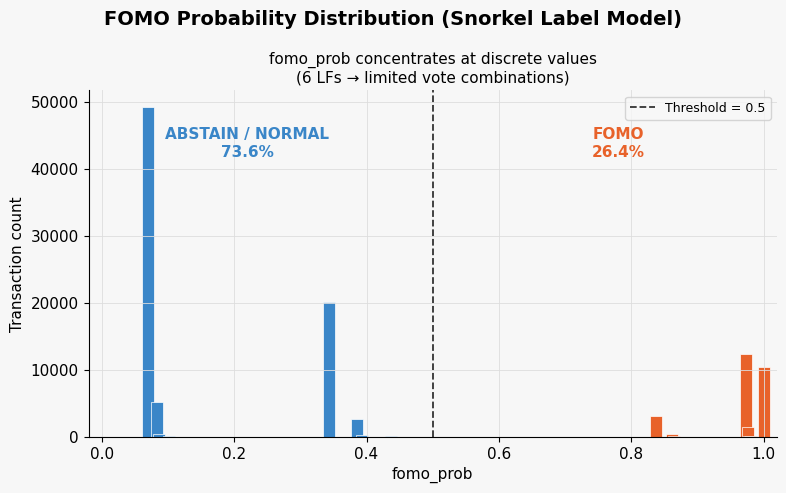

Saved → eda_lf_fig1_fomo_distribution.png


In [17]:
fig1, ax = plt.subplots(figsize=(8, 5))
fig1.suptitle('FOMO Probability Distribution (Snorkel Label Model)',
              fontsize=14, fontweight='bold')

prob_counts = df['fomo_prob'].round(3).value_counts().sort_index()
colors_bar  = [C_FOMO if x > 0.5 else C_NORMAL for x in prob_counts.index]

ax.bar(prob_counts.index, prob_counts.values,
       width=0.018, color=colors_bar, edgecolor='white', linewidth=0.5)

ax.axvline(0.5, linestyle='--', color='#333333', linewidth=1.3, label='Threshold = 0.5')

pct_fomo = (df['fomo_prob'] > 0.5).mean()
ax.text(0.78, prob_counts.max() * 0.85,
        f'FOMO\n{pct_fomo:.1%}', color=C_FOMO,
        fontsize=11, fontweight='bold', ha='center')
ax.text(0.22, prob_counts.max() * 0.85,
        f'ABSTAIN / NORMAL\n{1-pct_fomo:.1%}', color=C_NORMAL,
        fontsize=11, fontweight='bold', ha='center')

ax.set_xlabel('fomo_prob')
ax.set_ylabel('Transaction count')
ax.set_title('fomo_prob concentrates at discrete values\n'
             '(6 LFs → limited vote combinations)', fontsize=11)
ax.set_xlim(-0.02, 1.02)
ax.legend(fontsize=9)

fig1.tight_layout()
fig1.savefig(f'{OUTPUT_DIR}/eda_lf_fig1_fomo_distribution.png',
             dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()
print('Saved → eda_lf_fig1_fomo_distribution.png')

### 8.5 FIG 2 — LF Signals: RSI Extreme & Value Spike vs fomo_prob
- **Trái:** mean fomo_prob tăng đơn điệu theo RSI bucket → LF_rsi_extreme hoạt động đúng
- **Phải:** value_spike rate tăng theo quartile FOMO → LF_value_spike capture emotional capitulation

/tmp/ipykernel_6937/1077926689.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g['value_spike'] > 1).mean())


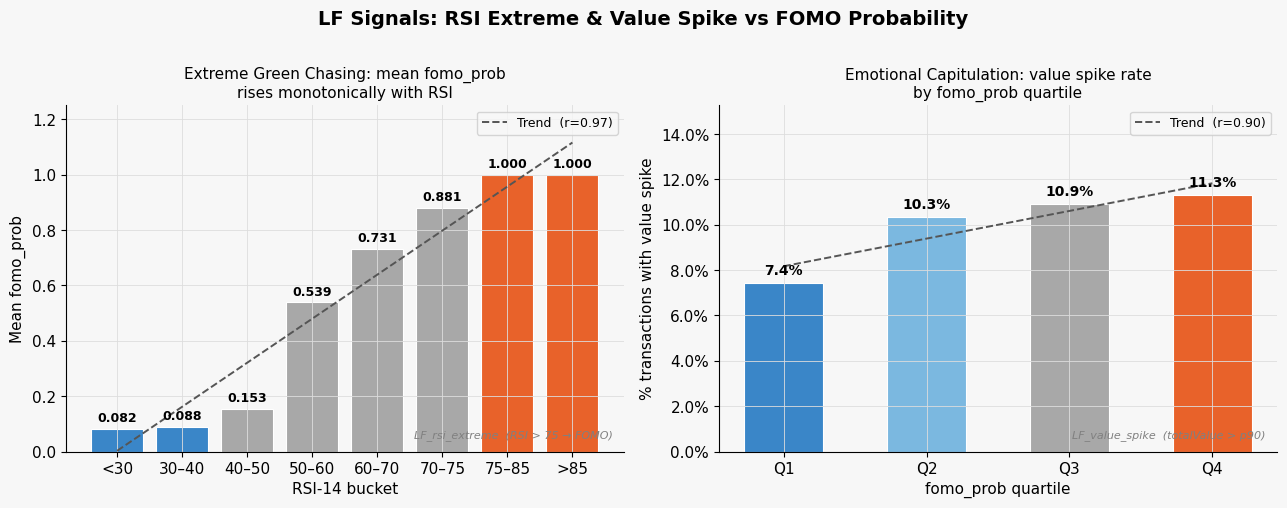

Saved → eda_lf_fig2_lf_signals.png


In [23]:
def mwu_label(a, b):
    """Mann-Whitney U significance label."""
    stat, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    if p < 0.001: return '*** p<.001'
    if p < 0.01:  return '**  p<.01'
    if p < 0.05:  return '*   p<.05'
    return f'ns  p={p:.3f}'

fig2, axes = plt.subplots(1, 2, figsize=(13, 5))
fig2.suptitle('LF Signals: RSI Extreme & Value Spike vs FOMO Probability',
              fontsize=14, fontweight='bold', y=1.01)

rsi_means  = df.groupby('rsi_bin', observed=True)['fomo_prob'].mean()
spike_rate = (df.groupby('fomo_q', observed=True)
                .apply(lambda g: (g['value_spike'] > 1).mean())
                .reindex(Q_LABELS))

# --- 2a: RSI bucket → mean fomo_prob ---
ax = axes[0]
rsi_colors = [C_FOMO   if any(z in str(l) for z in ['75–85', '>85']) else
              C_NORMAL if any(z in str(l) for z in ['<30', '30–40']) else
              C_MID    for l in rsi_means.index]

bars = ax.bar(rsi_means.index.astype(str), rsi_means.values,
              color=rsi_colors, edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt='%.3f', fontsize=9, padding=3, fontweight='bold')

x_num = np.arange(len(rsi_means))
slope, intercept, r, *_ = stats.linregress(x_num, rsi_means.values)
ax.plot(x_num, intercept + slope * x_num,
        linestyle='--', color='#555555', linewidth=1.4, label=f'Trend  (r={r:.2f})')
ax.set_xlabel('RSI-14 bucket')
ax.set_ylabel('Mean fomo_prob')
ax.set_title('Extreme Green Chasing: mean fomo_prob\nrises monotonically with RSI', fontsize=11)
ax.set_ylim(0, rsi_means.max() * 1.25)
ax.legend(fontsize=9)
ax.text(0.98, 0.04, 'LF_rsi_extreme  (RSI > 75 → FOMO)',
        transform=ax.transAxes, fontsize=8, color='grey', ha='right', style='italic')

# --- 2b: Value spike rate by fomo_prob quartile ---
ax = axes[1]
bars = ax.bar(Q_LABELS, spike_rate.values, color=PALETTE_Q,
              edgecolor='white', linewidth=0.8, width=0.55)
ax.bar_label(bars, fmt='{:.1%}', fontsize=10, padding=4, fontweight='bold')

slope, intercept, r, *_ = stats.linregress(np.arange(len(Q_LABELS)), spike_rate.values)
ax.plot(np.arange(len(Q_LABELS)), intercept + slope * np.arange(len(Q_LABELS)),
        linestyle='--', color='#555555', linewidth=1.4, label=f'Trend  (r={r:.2f})')
ax.set_xlabel('fomo_prob quartile')
ax.set_ylabel('% transactions with value spike')
ax.set_title('Emotional Capitulation: value spike rate\nby fomo_prob quartile', fontsize=11)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylim(0, spike_rate.max() * 1.35)
ax.legend(fontsize=9)
ax.text(0.98, 0.04, 'LF_value_spike  (totalValue > p90)',
        transform=ax.transAxes, fontsize=8, color='grey', ha='right', style='italic')

fig2.tight_layout()
fig2.savefig(f'{OUTPUT_DIR}/eda_lf_fig2_lf_signals.png',
             dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()
print('Saved → eda_lf_fig2_lf_signals.png')

### 8.6 FIG 3 — Rejected Features: risk_level & channel
Cả hai features này không phân biệt được Q1 (Rational) vs Q4 (FOMO) → bị loại khỏi model.

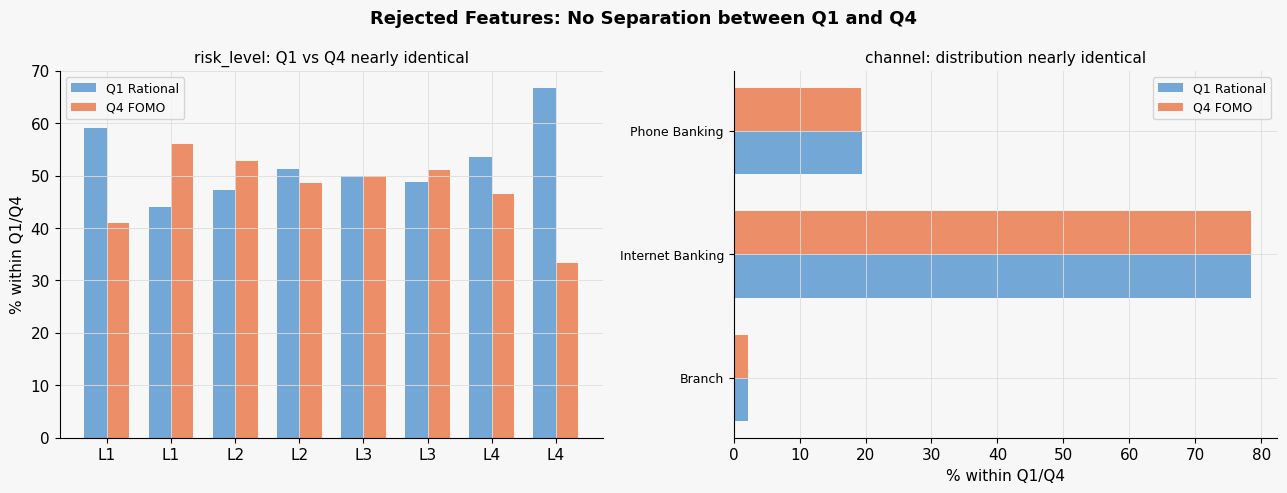

Saved → eda_fig3_rejected_features.png


In [25]:
fig3, axes = plt.subplots(1, 2, figsize=(13, 5))
fig3.suptitle('Rejected Features: No Separation between Q1 and Q4',
              fontsize=13, fontweight='bold')

# --- risk_level ---
ax = axes[0]
risk_pct = (q1q4.groupby(['risk_level', 'fomo_quartile'])
                .size().unstack(fill_value=0)
                .apply(lambda r: r / r.sum() * 100, axis=1))
x = np.arange(len(risk_pct))
w = 0.35
ax.bar(x - w/2, risk_pct.get('Q1', 0), width=w, color=C_NORMAL, alpha=0.7, label='Q1 Rational')
ax.bar(x + w/2, risk_pct.get('Q4', 0), width=w, color=C_FOMO,   alpha=0.7, label='Q4 FOMO')
ax.set_xticks(x)
ax.set_xticklabels([f'L{int(float(l))}' for l in risk_pct.index])
ax.set_title('risk_level: Q1 vs Q4 nearly identical', fontsize=11)
ax.set_ylabel('% within Q1/Q4')
ax.legend(fontsize=9)

# --- channel ---
ax = axes[1]
ch_pct = (q1q4.groupby(['channel', 'fomo_quartile'])
              .size().unstack(fill_value=0)
              .apply(lambda r: r / r.sum() * 100, axis=0))
y = np.arange(len(ch_pct))
ax.barh(y - w/2, ch_pct.get('Q1', 0), height=w, color=C_NORMAL, alpha=0.7, label='Q1 Rational')
ax.barh(y + w/2, ch_pct.get('Q4', 0), height=w, color=C_FOMO,   alpha=0.7, label='Q4 FOMO')
ax.set_yticks(y)
ax.set_yticklabels(ch_pct.index, fontsize=9)
ax.set_title('channel: distribution nearly identical', fontsize=11)
ax.set_xlabel('% within Q1/Q4')
ax.legend(fontsize=9)

fig3.tight_layout()
fig3.savefig(f'{OUTPUT_DIR}/eda_fig3_rejected_features.png',
             dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()
print('Saved → eda_fig3_rejected_features.png')

### 8.7 FIG 4 — Selected Features: position_size_ratio & macd_hist
Cả hai features này phân biệt rõ Q1 vs Q4 với p<.001 (Mann-Whitney U) → được giữ lại cho XGBoost.

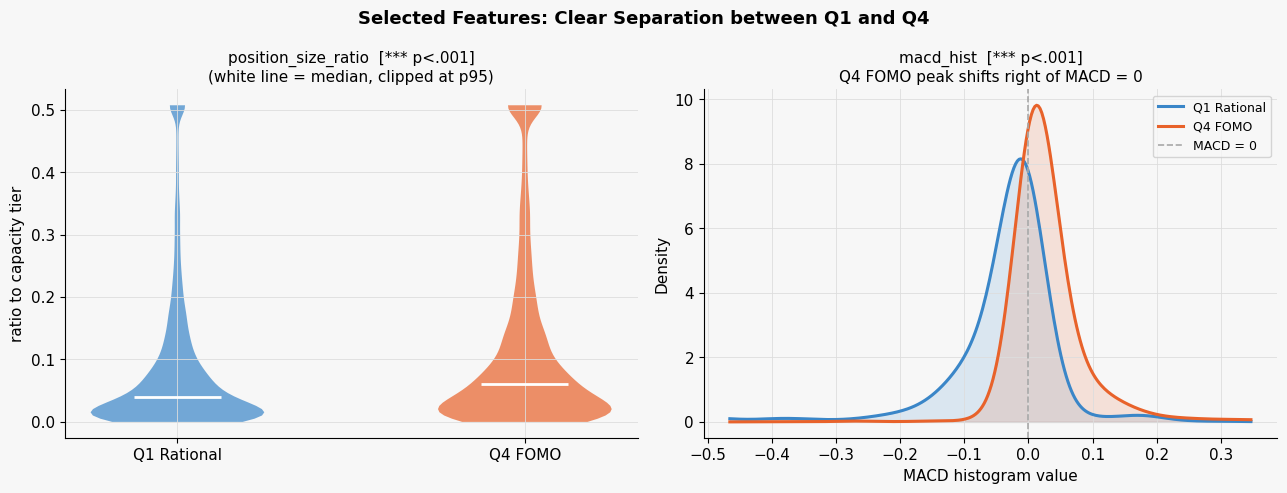

Saved → eda_fig4_selected_features.png


In [26]:
fig4, axes = plt.subplots(1, 2, figsize=(13, 5))
fig4.suptitle('Selected Features: Clear Separation between Q1 and Q4',
              fontsize=13, fontweight='bold')

# --- position_size_ratio: violin + clip outlier ---
ax = axes[0]
cap = q1q4['position_size_ratio'].quantile(0.95)
plot_df = q1q4[['fomo_quartile', 'position_size_ratio']].copy()
plot_df['position_size_ratio'] = plot_df['position_size_ratio'].clip(upper=cap)

parts = ax.violinplot(
    [plot_df[plot_df.fomo_quartile == g]['position_size_ratio'].dropna() for g in ['Q1', 'Q4']],
    positions=[1, 2], showmedians=True, showextrema=False)
for body, color in zip(parts['bodies'], [C_NORMAL, C_FOMO]):
    body.set_facecolor(color); body.set_alpha(0.7)
parts['cmedians'].set_color('white'); parts['cmedians'].set_linewidth(2)

sig = mwu_label(
    *[q1q4[q1q4.fomo_quartile == g]['position_size_ratio'].dropna() for g in ['Q1', 'Q4']]
)
ax.set_xticks([1, 2]); ax.set_xticklabels(['Q1 Rational', 'Q4 FOMO'])
ax.set_title(f'position_size_ratio  [{sig}]\n(white line = median, clipped at p95)', fontsize=11)
ax.set_ylabel('ratio to capacity tier')

# --- macd_hist: KDE overlay ---
ax = axes[1]
kde_x = np.linspace(q1q4['macd_hist'].quantile(0.01),
                    q1q4['macd_hist'].quantile(0.99), 300)
for grp, color, label in [('Q1', C_NORMAL, 'Q1 Rational'), ('Q4', C_FOMO, 'Q4 FOMO')]:
    vals = q1q4[q1q4.fomo_quartile == grp]['macd_hist'].dropna()
    kde  = stats.gaussian_kde(vals, bw_method=0.3)
    ax.plot(kde_x, kde(kde_x), color=color, linewidth=2.2, label=label)
    ax.fill_between(kde_x, kde(kde_x), alpha=0.15, color=color)

ax.axvline(0, linestyle='--', color=C_MID, linewidth=1.2, label='MACD = 0')
sig = mwu_label(
    *[q1q4[q1q4.fomo_quartile == g]['macd_hist'].dropna() for g in ['Q1', 'Q4']]
)
ax.set_title(f'macd_hist  [{sig}]\nQ4 FOMO peak shifts right of MACD = 0', fontsize=11)
ax.set_xlabel('MACD histogram value')
ax.set_ylabel('Density')
ax.legend(fontsize=9)

fig4.tight_layout()
fig4.savefig(f'{OUTPUT_DIR}/eda_fig4_selected_features.png',
             dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()
print('Saved → eda_fig4_selected_features.png')

---
## 8.8 Feature Engineering
Tích hợp từ `feature_engineering.py` — tính toàn bộ features cho XGBoost FOMO detection.

**Nguyên tắc:** Không dùng bất kỳ feature nào đã được dùng trong LF của Snorkel.

**Input:** `enriched_trades.parquet` + `snorkel_labels.csv`  
**Output:** `fomo_features.csv` — 1 row per BUY transaction, features + fomo_prob

**9 nhóm features:**
1. Investor Profile
2. Trading Habit
3. Position Sizing
4. Asset Switching
5. Crowd Alignment
6. Market Context
7. Asset Statistical
8. Rolling Behavioral Std
9. New Market Features (volatility_ratio, market_breadth, ema_12/26)

In [ ]:
# ── Paths (dùng variables đã định nghĩa ở Section 2) ──────────────────────────
# INPUT_LABELS → SNORKEL_LABELS_FILE  |  OUTPUT_FILE → FEATURES_FILE

# ════════════════════════════════════════════════════════════════════════════
# LOAD & SETUP
# ════════════════════════════════════════════════════════════════════════════

print("Loading data...")
df     = pd.read_parquet(ENRICHED_TRADES_PARQUET)
df["timestamp"] = pd.to_datetime(df["timestamp"])
labels = pd.read_csv(SNORKEL_LABELS_FILE)

buys = df[df["side"] == "BUY"].copy()
buys = buys.sort_values(["investor_id", "timestamp"]).reset_index(drop=True)
print(f"  BUY transactions: {len(buys):,}")

all_trades = df.sort_values(["investor_id", "timestamp"]).reset_index(drop=True)


# ════════════════════════════════════════════════════════════════════════════
# NHÓM 1 — INVESTOR PROFILE
# ════════════════════════════════════════════════════════════════════════════

# 1. risk_level — đã có sẵn
# 2. investment_capacity_ordinal — đã có sẵn

# 3. investor_trade_index
buys["investor_trade_index"] = buys.groupby("investor_id").cumcount()


# ════════════════════════════════════════════════════════════════════════════
# NHÓM 2 — TRADING HABIT
# ════════════════════════════════════════════════════════════════════════════

# 4. trade_gap_days
buys["trade_gap_days"] = (
    buys.groupby("investor_id")["timestamp"]
    .diff().dt.days
)

# 5. rolling_avg_trade_gap_last_10
buys["rolling_avg_trade_gap_last_10"] = (
    buys.groupby("investor_id")["trade_gap_days"]
    .transform(lambda x: x.shift(1).rolling(10, min_periods=3).mean())
)

# 6. trades_per_investor_per_day
buys["trades_per_investor_per_day"] = (
    buys.groupby(["investor_id", buys["timestamp"].dt.date]).transform("size")
)

# 7. digital_trade_flag
buys["digital_trade_flag"] = (buys["channel"] == "Internet Banking").astype(int)

# 8. consecutive_buy_streak
def compute_buy_streak(group):
    streak = []
    count = 0
    for side in group["side"]:
        if side == "BUY":
            count += 1
        else:
            count = 0
        streak.append(count)
    return streak

streaks = []
for inv_id, group in all_trades.groupby("investor_id"):
    s = compute_buy_streak(group)
    streaks.extend(list(zip(group.index, s)))

streak_series = pd.Series(dict(streaks), name="consecutive_buy_streak")
all_trades["consecutive_buy_streak"] = streak_series
buys = buys.merge(
    all_trades[["tx_id", "consecutive_buy_streak"]],
    on="tx_id", how="left"
)

# 9. rolling_buy_ratio_last_5
all_trades["is_buy"] = (all_trades["side"] == "BUY").astype(int)
all_trades["rolling_buy_ratio_last_5"] = (
    all_trades.groupby("investor_id")["is_buy"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=2).mean())
)
buys = buys.merge(
    all_trades[["tx_id", "rolling_buy_ratio_last_5"]],
    on="tx_id", how="left"
)

# 10. rolling_buy_ratio_last_20
all_trades["rolling_buy_ratio_last_20"] = (
    all_trades.groupby("investor_id")["is_buy"]
    .transform(lambda x: x.shift(1).rolling(20, min_periods=5).mean())
)
buys = buys.merge(
    all_trades[["tx_id", "rolling_buy_ratio_last_20"]],
    on="tx_id", how="left"
)

# 11. rolling_trade_freq_5
buys["rolling_trade_freq_5"] = (
    buys.groupby("investor_id")["trade_gap_days"]
    .transform(lambda x: 1 / (x.shift(1).rolling(5, min_periods=2).mean() + 1))
)


# ════════════════════════════════════════════════════════════════════════════
# NHÓM 3 — POSITION SIZING
# ════════════════════════════════════════════════════════════════════════════

# 12. position_size_ratio — đã có sẵn

# 13. position_size_spike_flag
p95_value = (
    buys.groupby("investor_id")["totalValue"]
    .transform(lambda x: x.shift(1).rolling(50, min_periods=5).quantile(0.95))
)
buys["position_size_spike_flag"] = (buys["totalValue"] > p95_value).astype(float)
buys.loc[p95_value.isna(), "position_size_spike_flag"] = np.nan

# 14. capital_acceleration_ratio
rolling_mean_10 = (
    buys.groupby("investor_id")["totalValue"]
    .transform(lambda x: x.shift(1).rolling(10, min_periods=3).mean())
)
buys["capital_acceleration_ratio"] = buys["totalValue"] / rolling_mean_10.replace(0, np.nan)

# 15. rolling_avg_position_size_last_10
buys["rolling_avg_position_size_last_10"] = (
    buys.groupby("investor_id")["totalValue"]
    .transform(lambda x: x.shift(1).rolling(10, min_periods=3).mean())
)

# 16. position_size_to_volatility_ratio
buys["position_size_to_volatility_ratio"] = (
    buys["totalValue"] / (buys["volatility_10d"].replace(0, np.nan) * buys["totalValue"].mean())
)


# ════════════════════════════════════════════════════════════════════════════
# NHÓM 4 — ASSET SWITCHING
# ════════════════════════════════════════════════════════════════════════════

# 17. is_new_asset
buys["prev_asset_id"] = buys.groupby("investor_id")["asset_id"].shift(1)
buys["is_new_asset"] = (
    (buys["asset_id"] != buys["prev_asset_id"]) & buys["prev_asset_id"].notna()
).astype(float)
buys.loc[buys["prev_asset_id"].isna(), "is_new_asset"] = np.nan

# 18. asset_diversity_last_10
buys["asset_id_code"] = buys["asset_id"].astype("category").cat.codes
buys["asset_diversity_last_10"] = (
    buys.groupby("investor_id")["asset_id_code"]
    .transform(lambda x: x.shift(1).rolling(10, min_periods=3)
               .apply(lambda w: len(set(w.astype(int))), raw=True))
)
buys = buys.drop(columns=["asset_id_code"])

# 19. same_day_multiple_flag
buys["same_day_multiple_flag"] = (buys["trades_per_investor_per_day"] >= 2).astype(int)


# ════════════════════════════════════════════════════════════════════════════
# NHÓM 5 — CROWD ALIGNMENT
# ════════════════════════════════════════════════════════════════════════════

# 20. investor_alignment_with_crowd
daily_market = (
    df.groupby(df["timestamp"].dt.date)["side"]
    .apply(lambda x: (x == "BUY").sum() / len(x))
    .reset_index()
    .rename(columns={"timestamp": "date", "side": "market_buy_ratio"})
)
buys["date"] = buys["timestamp"].dt.date
buys = buys.merge(daily_market, on="date", how="left")
buys["investor_alignment_with_crowd"] = (buys["market_buy_ratio"] > 0.7).astype(int)

# 21. asset_popularity_zscore
asset_daily = (
    df[df["side"] == "BUY"]
    .groupby(["asset_id", df["timestamp"].dt.date.rename("date")])
    .size()
    .reset_index(name="daily_buy_count")
)
asset_daily["asset_popularity_zscore"] = (
    asset_daily.groupby("asset_id")["daily_buy_count"]
    .transform(lambda x: (x - x.rolling(60, min_periods=10).mean().shift(1)) /
               (x.rolling(60, min_periods=10).std().shift(1) + 1e-8))
)
buys = buys.merge(
    asset_daily[["asset_id", "date", "asset_popularity_zscore"]],
    on=["asset_id", "date"], how="left"
)


# ════════════════════════════════════════════════════════════════════════════
# NHÓM 6 — MARKET CONTEXT SẠCH
# ════════════════════════════════════════════════════════════════════════════

# 22. return_1d — đã có sẵn
# 23. volatility_10d — đã có sẵn

# 24. volatility_regime
buys["volatility_regime"] = pd.qcut(
    buys["volatility_10d"].fillna(buys["volatility_10d"].median()),
    q=3, labels=[0, 1, 2]
).astype(float)

# 25. momentum_acceleration
if "return_3d" in buys.columns and "return_10d" in buys.columns:
    buys["momentum_acceleration"] = buys["return_3d"] - buys["return_10d"]
else:
    buys["momentum_acceleration"] = np.nan


# ════════════════════════════════════════════════════════════════════════════
# NHÓM 7 — ASSET STATISTICAL
# ════════════════════════════════════════════════════════════════════════════

# 26. total_value_pctrank_asset
buys["total_value_pctrank_asset"] = (
    buys.groupby("asset_id")["totalValue"]
    .transform(lambda x: x.rank(pct=True))
)

# 27. volatility_10d_pctrank_asset
buys["volatility_10d_pctrank_asset"] = (
    buys.groupby("asset_id")["volatility_10d"]
    .transform(lambda x: x.rank(pct=True))
)

# 28. market_fomo_pressure_score
buys["market_fomo_pressure_score"] = (
    buys["asset_popularity_zscore"].fillna(0).clip(-3, 3) / 3 * 0.4 +
    buys["investor_alignment_with_crowd"].fillna(0) * 0.3 +
    buys["volatility_regime"].fillna(1) / 2 * 0.3
).clip(0, 1)


# ════════════════════════════════════════════════════════════════════════════
# NHÓM 8 — ROLLING BEHAVIORAL STD
# ════════════════════════════════════════════════════════════════════════════

# 29. return_1d_rolling_std_10
buys["return_1d_rolling_std_10"] = (
    buys.groupby("investor_id")["return_1d"]
    .transform(lambda x: x.shift(1).rolling(10, min_periods=3).std())
)

# 30. volatility_5d_rolling_std_10
buys["volatility_5d_rolling_std_10"] = (
    buys.groupby("investor_id")["volatility_5d"]
    .transform(lambda x: x.shift(1).rolling(10, min_periods=3).std())
)


# ════════════════════════════════════════════════════════════════════════════
# NHÓM 9 — NEW MARKET FEATURES
# ════════════════════════════════════════════════════════════════════════════

# 31. volatility_ratio  32. market_breadth  33. ema_12  34. ema_26
# → đã tính trong data_builder.py, kiểm tra và warn nếu thiếu
for new_col in ["volatility_ratio", "market_breadth", "ema_12", "ema_26"]:
    if new_col not in buys.columns:
        print(f"  [WARNING] {new_col} không có trong enriched file")
        print(f"            → Chạy lại make_clean_data.py với data_builder.py mới")
        buys[new_col] = np.nan


# ════════════════════════════════════════════════════════════════════════════
# OUTPUT
# ════════════════════════════════════════════════════════════════════════════

FEATURE_COLS = [
    # Investor profile
    "risk_level", "investment_capacity_ordinal", "investor_trade_index",
    # Trading habit
    "trade_gap_days", "rolling_avg_trade_gap_last_10", "trades_per_investor_per_day",
    "digital_trade_flag", "consecutive_buy_streak",
    "rolling_buy_ratio_last_5", "rolling_buy_ratio_last_20", "rolling_trade_freq_5",
    # Position sizing
    "position_size_ratio", "position_size_spike_flag", "capital_acceleration_ratio",
    "rolling_avg_position_size_last_10", "position_size_to_volatility_ratio",
    # Asset switching
    "is_new_asset", "asset_diversity_last_10", "same_day_multiple_flag",
    # Crowd alignment
    "investor_alignment_with_crowd", "asset_popularity_zscore",
    # Market context
    "return_1d", "volatility_10d", "volatility_regime", "momentum_acceleration",
    # Asset statistical
    "total_value_pctrank_asset", "volatility_10d_pctrank_asset", "market_fomo_pressure_score",
    # Behavioral std
    "return_1d_rolling_std_10", "volatility_5d_rolling_std_10",
    # New market features
    "volatility_ratio", "market_breadth", "ema_12", "ema_26",
]

# Join với snorkel labels
result = buys[["tx_id", "investor_id", "timestamp"] + FEATURE_COLS].merge(
    labels[["tx_id", "fomo_prob", "all_abstain"]],
    on="tx_id", how="inner"
)

# Drop all-abstain
before = len(result)
result = result[~result["all_abstain"]].drop(columns=["all_abstain"])
print(f"\n  Dropped all-abstain: {before - len(result):,} rows")
print(f"  Training set: {len(result):,} rows")

os.makedirs(OUTPUT_DIR, exist_ok=True)
result.to_csv(FEATURES_FILE, index=False)
print(f"\n✓ Saved: {FEATURES_FILE}")
print(f"  Shape: {result.shape}")
print(f"  Features: {len(FEATURE_COLS)}")

print("\nNaN summary:")
nan_pct = result[FEATURE_COLS].isna().mean() * 100
nan_pct = nan_pct[nan_pct > 0].sort_values(ascending=False)
for col, pct in nan_pct.items():
    print(f"  {col:<40} {pct:.1f}%")

print("\nfomo_prob distribution:")
print(f"  Mean  : {result['fomo_prob'].mean():.4f}")
print(f"  Median: {result['fomo_prob'].median():.4f}")
print(f"  > 0.65: {(result['fomo_prob'] > 0.65).mean()*100:.1f}%")
print(f"  < 0.35: {(result['fomo_prob'] < 0.35).mean()*100:.1f}%")
print(f"  0.35-0.65: {((result['fomo_prob'] >= 0.35) & (result['fomo_prob'] <= 0.65)).mean()*100:.1f}%")
print("\n✓ Done. Next: Feature Validation (Section 9).")


---
## 9. Feature Validation
Kiểm tra feature set trước khi train XGBoost. Chạy sau khi có `fomo_features.csv` và `lf_input.csv`.

**Flow:**
- **9.1** — Setup: load files, define helpers
- **9.2** — STEP 1: Sanity checks (shape, NaN, constant cols, dtypes)
- **9.3** — STEP 2: Leakage check (Spearman vs LF inputs)
- **9.4** — STEP 3: Feature quality (outliers, redundancy, near-zero variance)
- **9.5** — STEP 4: Label distribution + signal check
- **9.6** — Summary & action items


### 9.1 Setup — Load Files & Helpers

In [ ]:
# ── Config ───────────────────────────────────────────────────────────────
LEAKAGE_THRESHOLD = 0.5

LF_INPUT_COLS = [
    "return_5d",
    "rsi_14",
    "price_above_bollinger",
    "price_below_bollinger",
    "asset_buy_count_same_day",
    "asset_buy_count_p95_60d",
    "totalValue",
    "p90_trade_value",
    "days_since_last_buy",
]

def sep(title="", width=60):
    if title:
        print(f"\n{'='*width}")
        print(f"  {title}")
        print(f"{'='*width}")
    else:
        print("=" * width)

# ── Load ──────────────────────────────────────────────────────────────────
sep("LOADING DATA")
features_df = pd.read_csv(FEATURES_FILE, parse_dates=["timestamp"])
lf_input_df = pd.read_csv(LF_INPUT_FILE, parse_dates=["timestamp"])

merged = features_df.merge(
    lf_input_df[["tx_id"] + LF_INPUT_COLS],
    on="tx_id", how="left"
)

META_COLS = ["tx_id", "investor_id", "timestamp", "fomo_prob"]
FEAT_COLS = [c for c in features_df.columns if c not in META_COLS]

print(f"  Features file: {features_df.shape}")
print(f"  LF input file: {lf_input_df.shape}")
print(f"  Merged shape:  {merged.shape}")
print(f"  Feature columns ({len(FEAT_COLS)}): {FEAT_COLS}")

# Tích lũy các cột bị loại qua từng bước
dropped_cols = set()

def active_feats():
    return [c for c in FEAT_COLS if c not in dropped_cols]


### 9.2 STEP 1 — Sanity Checks

In [ ]:
sep("STEP 1: SANITY CHECKS")

# 1a. Shape
print(f"\n[1a] Shape: {features_df.shape}")
print(f"     Rows: {len(features_df):,} | Features: {len(FEAT_COLS)}")

# 1b. Duplicate rows
n_dup = features_df.duplicated(subset=["tx_id"]).sum()
print(f"\n[1b] Duplicate tx_id: {n_dup}")
if n_dup > 0:
    print(f"     ⚠️  WARNING: {n_dup} duplicate tx_ids — kiểm tra join logic")
else:
    print(f"     ✓ Không có duplicate")

# 1c. NaN rate per feature
print(f"\n[1c] NaN rate per feature:")
nan_rates = features_df[active_feats()].isna().mean().sort_values(ascending=False)
high_nan = nan_rates[nan_rates > 0.3]
med_nan  = nan_rates[(nan_rates > 0.05) & (nan_rates <= 0.3)]
low_nan  = nan_rates[(nan_rates > 0) & (nan_rates <= 0.05)]
zero_nan = nan_rates[nan_rates == 0]

print(f"     NaN = 0%:        {len(zero_nan)} features ✓")
print(f"     NaN 0-5%:        {len(low_nan)} features (acceptable)")
print(f"     NaN 5-30%:       {len(med_nan)} features (check warmup)")
print(f"     NaN > 30%:       {len(high_nan)} features ⚠️")

if len(high_nan) > 0:
    print(f"\n     Features với NaN > 30% → bị loại:")
    for col, rate in high_nan.items():
        print(f"       DROP {col:<45} {rate*100:.1f}%")
        dropped_cols.add(col)

if len(med_nan) > 0:
    print(f"\n     Features với NaN 5-30% (warmup expected):")
    for col, rate in med_nan.items():
        print(f"       {col:<45} {rate*100:.1f}%")

# 1d. Constant / near-constant
print(f"\n[1d] Constant / near-constant columns (nunique <= 2):")
_found_const = False
for col in active_feats():
    n_unique = features_df[col].nunique(dropna=True)
    if n_unique <= 1:
        print(f"     ⚠️  CONSTANT: {col} (nunique={n_unique}) → DROP")
        dropped_cols.add(col); _found_const = True
    elif n_unique == 2:
        dom = features_df[col].value_counts(normalize=True).iloc[0]
        if dom > 0.95:
            print(f"     ⚠️  NEAR-CONSTANT: {col} — dominant {dom*100:.1f}% → DROP")
            dropped_cols.add(col); _found_const = True
if not _found_const:
    print(f"     ✓ Không có constant/near-constant column")

# 1e. Data type check
print(f"\n[1e] Non-numeric features:")
non_numeric = [c for c in active_feats() if features_df[c].dtype == "object"]
if non_numeric:
    for col in non_numeric:
        print(f"     ⚠️  {col}: {features_df[col].dtype} → DROP")
        dropped_cols.add(col)
else:
    print(f"     ✓ Tất cả features đều numeric")

print(f"\n  → Sau Step 1: loại {len(dropped_cols)} features, còn lại {len(active_feats())}")


### 9.3 STEP 2 — Leakage Check (Spearman vs LF Inputs)

In [ ]:
sep("STEP 2: LEAKAGE CHECK — Spearman vs LF Inputs")

step2_feats = active_feats()
print(f"\n  Features đưa vào check: {len(step2_feats)} (đã bỏ {len(dropped_cols)} từ Step 1)")
print(f"  Threshold: |rho| > {LEAKAGE_THRESHOLD} → flag leakage")
print(f"  LF inputs checked: {LF_INPUT_COLS}\n")

leakage_flags = []
leakage_table = []

for feat in step2_feats:
    row = {"feature": feat}
    max_rho, max_lf = 0, ""
    for lf_col in LF_INPUT_COLS:
        mask = merged[feat].notna() & merged[lf_col].notna()
        if mask.sum() < 100:
            row[lf_col] = np.nan; continue
        rho, _ = stats.spearmanr(merged.loc[mask, feat], merged.loc[mask, lf_col])
        row[lf_col] = round(rho, 3)
        if abs(rho) > abs(max_rho):
            max_rho, max_lf = rho, lf_col
    row["max_|rho|"] = round(abs(max_rho), 3)
    row["max_lf"]    = max_lf
    leakage_table.append(row)
    if abs(max_rho) > LEAKAGE_THRESHOLD:
        leakage_flags.append((feat, max_lf, max_rho))

leakage_df = pd.DataFrame(leakage_table).set_index("feature")

print(f"  {'Feature':<45} {'Max |rho|':>10}  {'With LF input'}")
print(f"  {'-'*45} {'-'*10}  {'-'*25}")
for _, row in leakage_df.sort_values("max_|rho|", ascending=False).iterrows():
    flag = "⚠️  LEAKAGE" if row["max_|rho|"] > LEAKAGE_THRESHOLD else "✓"
    print(f"  {row.name:<45} {row['max_|rho|']:>10.3f}  {row['max_lf']:<25} {flag}")

if leakage_flags:
    print(f"\n  ⚠️  {len(leakage_flags)} features bị flag leakage → DROP:")
    for feat, lf_col, rho in sorted(leakage_flags, key=lambda x: abs(x[2]), reverse=True):
        print(f"     DROP: {feat:<40}  rho={rho:+.3f} với {lf_col}")
        dropped_cols.add(feat)
else:
    print(f"\n  ✓ Không có feature nào vượt threshold {LEAKAGE_THRESHOLD}")

leakage_df.to_csv(f"{OUTPUT_DIR}/leakage_check.csv")
print(f"\n  Saved: {OUTPUT_DIR}/leakage_check.csv")
print(f"\n  → Sau Step 2: loại tổng {len(dropped_cols)} features, còn lại {len(active_feats())}")


### 9.4 STEP 3 — Feature Quality Check

In [ ]:
sep("STEP 3: FEATURE QUALITY CHECK")

step3_feats = active_feats()
print(f"\n  Features đưa vào check: {len(step3_feats)} (đã bỏ {len(dropped_cols)} từ Step 1-2)")

# 3a. Basic stats
print(f"\n[3a] Descriptive statistics:")
desc = features_df[step3_feats].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99])
print(desc.T[["mean", "std", "min", "1%", "50%", "99%", "max"]].to_string())

# 3b. Outlier check
print(f"\n[3b] Extreme outliers (ngoài mean ± 5*std):")
_found_outlier = False
for col in step3_feats:
    series = features_df[col].dropna()
    if len(series) < 10: continue
    mean, std = series.mean(), series.std()
    if std == 0: continue
    pct = ((series - mean).abs() > 5 * std).mean() * 100
    if pct > 1.0:
        print(f"  ⚠️  {col:<45} {pct:.1f}% extreme values — consider clipping")
        _found_outlier = True
if not _found_outlier:
    print(f"  ✓ Không có feature nào có quá 1% extreme values")

# 3c. Redundancy check
print(f"\n[3c] Highly correlated feature pairs (|rho| > 0.85 → redundant):")
numeric_feats     = [c for c in step3_feats if features_df[c].dtype != "object"]
corr_matrix       = features_df[numeric_feats].corr(method="spearman")
redundant_pairs   = []
redundant_to_drop = set()
for i in range(len(numeric_feats)):
    for j in range(i+1, len(numeric_feats)):
        rho = corr_matrix.iloc[i, j]
        if abs(rho) > 0.85:
            f1, f2 = numeric_feats[i], numeric_feats[j]
            redundant_pairs.append((f1, f2, rho))
            redundant_to_drop.add(f2)

if redundant_pairs:
    for f1, f2, rho in sorted(redundant_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"  ⚠️  {f1:<40} × {f2:<40}  rho={rho:+.3f}  DROP: {f2}")
    dropped_cols.update(redundant_to_drop)
    print(f"\n  → Loại {len(redundant_to_drop)} redundant features")
else:
    print(f"  ✓ Không có cặp nào vượt threshold 0.85")

# 3d. Near-zero variance
print(f"\n[3d] Near-zero variance (CV < 0.01):")
_found_nzv = False
for col in active_feats():
    series = features_df[col].dropna()
    if len(series) < 10 or series.mean() == 0: continue
    cv = series.std() / abs(series.mean())
    if cv < 0.01:
        print(f"  ⚠️  {col:<45} CV={cv:.4f} → DROP")
        dropped_cols.add(col); _found_nzv = True
if not _found_nzv:
    print(f"  ✓ Tất cả features có variance đủ lớn")

print(f"\n  → Sau Step 3: loại tổng {len(dropped_cols)} features, còn lại {len(active_feats())}")


### 9.5 STEP 4 — Label Distribution & Signal Check

In [ ]:
sep("STEP 4: LABEL DISTRIBUTION CHECK")

step4_feats = active_feats()
print(f"\n  Features đưa vào check: {len(step4_feats)} (đã bỏ {len(dropped_cols)} từ Step 1-3)")

fomo = features_df["fomo_prob"]

print(f"\n[4a] fomo_prob distribution:")
print(f"     N       : {len(fomo):,}")
print(f"     Mean    : {fomo.mean():.4f}")
print(f"     Median  : {fomo.median():.4f}")
print(f"     Std     : {fomo.std():.4f}")
print(f"     Min/Max : {fomo.min():.4f} / {fomo.max():.4f}")

print(f"\n[4b] fomo_prob buckets:")
buckets = [0.0, 0.2, 0.4, 0.6, 0.8, 1.01]
labels  = ["[0.0, 0.2)", "[0.2, 0.4)", "[0.4, 0.6)", "[0.6, 0.8)", "[0.8, 1.0]"]
for i, label in enumerate(labels):
    mask = (fomo >= buckets[i]) & (fomo < buckets[i+1])
    bar  = "█" * int(mask.mean() * 50)
    print(f"     {label}  {bar:<50} {mask.sum():>7,} ({mask.mean()*100:5.1f}%)")

print(f"\n[4c] Binarize estimate (threshold = 0.5):")
fomo_binary = (fomo > 0.5).astype(int)
n_fomo   = fomo_binary.sum()
n_normal = len(fomo_binary) - n_fomo
ratio    = n_fomo / len(fomo_binary)
print(f"     FOMO   (1): {n_fomo:>7,} ({ratio*100:.1f}%)")
print(f"     NORMAL (0): {n_normal:>7,} ({(1-ratio)*100:.1f}%)")
if ratio < 0.1 or ratio > 0.6:
    print(f"     ⚠️  Class imbalance — scale_pos_weight = {n_normal/n_fomo:.2f}")
else:
    print(f"     ✓ Class balance acceptable")

print(f"\n[4d] Correlation với fomo_prob — {len(step4_feats)} features còn lại:")
label_corr = []
for col in step4_feats:
    mask = features_df[col].notna() & fomo.notna()
    if mask.sum() < 100: continue
    rho, pval = stats.spearmanr(features_df.loc[mask, col], fomo[mask])
    label_corr.append((col, rho, pval))

label_corr_df = pd.DataFrame(label_corr, columns=["feature", "rho", "pval"])
label_corr_df = label_corr_df.reindex(
    label_corr_df["rho"].abs().sort_values(ascending=False).index
)

print(f"\n     {'Feature':<45} {'rho':>8}  {'p-value':>12}  Signal?")
print(f"     {'-'*45} {'-'*8}  {'-'*12}  -------")
for _, row in label_corr_df.iterrows():
    sig = "✓ strong" if abs(row["rho"]) > 0.15 else (
          "~ weak"   if abs(row["rho"]) > 0.05 else "✗ no signal")
    print(f"     {row['feature']:<45} {row['rho']:>+8.3f}  {row['pval']:>12.2e}  {sig}")

no_signal = label_corr_df[label_corr_df["rho"].abs() <= 0.05]
if len(no_signal) > 0:
    print(f"\n     ⚠️  {len(no_signal)} features gần như không correlate với label:")
    for _, row in no_signal.iterrows():
        print(f"       {row['feature']:<45} rho={row['rho']:+.4f}")
    dropped_cols.update(no_signal["feature"].tolist())

print(f"\n  → Sau Step 4: loại tổng {len(dropped_cols)} features, còn lại {len(active_feats())}")


### 9.6 Summary — Action Items

In [ ]:
sep("SUMMARY — ACTION ITEMS")

final_feats = active_feats()
print(f"\n  Tổng features ban đầu : {len(FEAT_COLS)}")
print(f"  Tổng features bị loại : {len(dropped_cols)}")
print(f"  Features còn lại      : {len(final_feats)}")

if dropped_cols:
    print(f"  {'─'*45}")
    print(f"  Features bị loại:")
    for col in sorted(dropped_cols):
        print(f"    - {col}")

issues = []
if n_dup > 0:
    issues.append(f"[CRITICAL]  {n_dup} duplicate tx_ids — fix join logic")
if ratio < 0.1 or ratio > 0.6:
    issues.append(f"[IMBALANCE] scale_pos_weight = {n_normal/n_fomo:.2f} cho XGBoost")

if len(issues) == 0:
    print(f"\n  ✓ Không có issue bổ sung. Feature set sẵn sàng để train XGBoost.")
else:
    print(f"\n  {len(issues)} items còn cần xử lý:")
    for item in issues:
        print(f"     {item}")

print(f"\n✓ Done. Files saved:")
print(f"  {OUTPUT_DIR}/leakage_check.csv")
print(f"\nNext step: chạy Section 10 — XGBoost Training với {len(final_feats)} features")


---
## 10. XGBoost Training
**Flow:** Load features → Optuna tuning (TS-CV) → Evaluate → Train final model → Save artifacts

Output files:
- `model/xgboost_fomo.ubj` — final model
- `model/optuna_best_params.json` — best hyperparameters
- `model/run_metadata.json` — full run summary (config + metrics)


### 10.1 Config & Load Features

In [ ]:
# ── Config ───────────────────────────────────────────────────────────────
RANDOM_STATE     = 42
OPTUNA_TRIALS    = 50
OPTUNA_TIMEOUT   = 300
WEIGHT_EPSILON   = 0.01
CV_FOLDS         = 5

FOMO_HIGH_THRESH   = 0.65
FOMO_LOW_THRESH    = 0.35
FOMO_MEDIUM_THRESH = 0.40

NON_FEATURE_COLS = [
    "tx_id", "investor_id", "timestamp", "fomo_prob", "momentum_acceleration",
    "trade_gap_days", "total_value_pctrank_asset", "rolling_avg_position_size_last_10",
    "position_size_to_volatility_ratio", "position_size_ratio", "trades_per_investor_per_day",
    "same_day_multiple_flag", "return_1d", "market_fomo_pressure_score",
    "asset_popularity_zscore", "volatility_regime", "rolling_trade_freq_5",
    "price_distance_high", "macd", "macd_hist", "macd_signal",
    "investor_trade_index", "volatility_5d_rolling_std_10", "volatility_10d",
    "risk_level", "return_1d_rolling_std_10", "volatility_10d_pctrank_asset",
    "digital_trade_flag"
]

def prepare(subset, feature_cols):
    X = subset[feature_cols].fillna(subset[feature_cols].median())
    y = subset["fomo_prob"].values
    w = np.abs(y - 0.5) * 2 + WEIGHT_EPSILON
    return X, y, w

print("🚀 Loading features...")
df_train = pd.read_csv(FEATURES_FILE, parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
feature_cols = [c for c in df_train.columns if c not in NON_FEATURE_COLS]
X_full, y_full, w_full = prepare(df_train, feature_cols)
print(f"  {len(df_train):,} rows | {len(feature_cols)} features")


### 10.2 Optuna Tuning (TS-CV) + Save params

In [ ]:
tscv = TimeSeriesSplit(n_splits=CV_FOLDS)

def objective(trial):
    params = {
        "objective": "reg:logistic", "eval_metric": "logloss", "tree_method": "hist",
        "n_estimators":     trial.suggest_int("n_estimators", 100, 800),
        "max_depth":        trial.suggest_int("max_depth", 3, 8),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state":     RANDOM_STATE
    }
    scores = []
    for tr_idx, val_idx in tscv.split(X_full):
        model = xgb.XGBRegressor(**params)
        model.fit(X_full.iloc[tr_idx], y_full[tr_idx], sample_weight=w_full[tr_idx])
        p = np.clip(model.predict(X_full.iloc[val_idx]), 1e-7, 1 - 1e-7)
        scores.append(log_loss((y_full[val_idx] > 0.5).astype(int), p, sample_weight=w_full[val_idx]))
    return np.mean(scores)

print(f"🎯 Optuna tuning ({OPTUNA_TRIALS} trials)...")
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=OPTUNA_TRIALS, timeout=OPTUNA_TIMEOUT)
best_params = study.best_params

print(f"\n🎯 Best CV LogLoss: {study.best_value:.6f}")
print("📌 Best Hyperparameters found:")
for k, v in best_params.items():
    print(f"    {k:<20}: {v}")

# ── Save Optuna params ────────────────────────────────────────────────────
os.makedirs(MODEL_DIR, exist_ok=True)
with open(OPTUNA_PARAMS_FILE, "w") as f:
    json.dump({
        "best_params":     best_params,
        "best_cv_logloss": study.best_value,
        "n_trials":        OPTUNA_TRIALS,
        "n_completed":     len(study.trials),
        "timeout_sec":     OPTUNA_TIMEOUT,
    }, f, indent=4)
print(f"\n✓ Optuna params saved → {OPTUNA_PARAMS_FILE}")


### 10.3 Evaluation (TS-CV) — XGBoost vs Mean Baseline

In [ ]:
print("📊 Evaluation via TimeSeriesSplit CV...")
df_hc = df_train[(df_train["fomo_prob"] > FOMO_HIGH_THRESH) | (df_train["fomo_prob"] < FOMO_LOW_THRESH)].copy()
df_hc["fomo_label"] = (df_hc["fomo_prob"] > FOMO_HIGH_THRESH).astype(int)
X_hc, y_hc, w_hc = prepare(df_hc, feature_cols)

cv_res    = []
oof_preds = np.full(len(df_hc), np.nan)

for tr_idx, te_idx in tscv.split(X_hc):
    m = xgb.XGBRegressor(objective="reg:logistic", **best_params)
    m.fit(X_hc.iloc[tr_idx], df_hc["fomo_label"].values[tr_idx], sample_weight=w_hc[tr_idx])
    p = np.clip(m.predict(X_hc.iloc[te_idx]), 1e-7, 1 - 1e-7)
    oof_preds[te_idx] = p
    cv_res.append([
        roc_auc_score(df_hc["fomo_label"].values[te_idx], p),
        log_loss(df_hc["fomo_label"].values[te_idx], p),
        np.sqrt(mean_squared_error(df_hc["fomo_label"].values[te_idx], p))
    ])

valid_mask = ~np.isnan(oof_preds)
y_valid    = df_hc["fomo_label"].values[valid_mask]
p_valid    = oof_preds[valid_mask]

baseline_preds = np.full(len(y_valid), y_valid.mean())
base_mae   = mean_absolute_error(y_valid, baseline_preds)
base_rmse  = np.sqrt(mean_squared_error(y_valid, baseline_preds))
base_r2    = r2_score(y_valid, baseline_preds)
model_mae  = mean_absolute_error(y_valid, p_valid)
model_rmse = np.sqrt(mean_squared_error(y_valid, p_valid))
model_r2   = r2_score(y_valid, p_valid)
mean_auc   = np.mean([r[0] for r in cv_res])
std_auc    = np.std([r[0] for r in cv_res])

print("\n" + "=" * 70)
print("FINAL PERFORMANCE SUMMARY — REGRESSION EVALUATION")
print("=" * 70)
print(f"\n{'Strategy':<35} | {'MAE':<10} | {'RMSE':<10} | {'R²':<10}")
print(f"{'Mean Baseline':<35} | {base_mae:<10.4f} | {base_rmse:<10.4f} | {base_r2:<10.4f}")
print(f"{'Proposed XGBoost Model':<35} | {model_mae:<10.4f} | {model_rmse:<10.4f} | {model_r2:<10.4f}")
print(f"\nImprovement over Baseline:")
print(f"  MAE  reduction : {(base_mae - model_mae) / base_mae * 100:+.2f}%")
print(f"  RMSE reduction : {(base_rmse - model_rmse) / base_rmse * 100:+.2f}%")
print(f"  R²   gain      : {model_r2 - base_r2:+.4f}")
print(f"\nLabel Learnability Score (CV):")
print(f"  Mean AUC = {mean_auc:.4f} ± {std_auc:.4f}")


### 10.4 Train Final Model & Save Artifacts

In [ ]:
# ── Train final model trên toàn bộ data ──────────────────────────────────
print("🏋️ Training final model on full dataset...")
final_model = xgb.XGBRegressor(objective="reg:logistic", **best_params)
final_model.fit(X_full, y_full, sample_weight=w_full)

os.makedirs(MODEL_DIR, exist_ok=True)
final_model.save_model(XGBOOST_MODEL_FILE)
print(f"✓ Model saved          → {XGBOOST_MODEL_FILE}")

# ── Save run metadata ─────────────────────────────────────────────────────
run_metadata = {
    "saved_at":   datetime.datetime.now().isoformat(timespec="seconds"),
    "model_file": XGBOOST_MODEL_FILE,
    "optuna_params_file": OPTUNA_PARAMS_FILE,
    "config": {
        "random_state":   RANDOM_STATE,
        "optuna_trials":  OPTUNA_TRIALS,
        "optuna_timeout": OPTUNA_TIMEOUT,
        "cv_folds":       CV_FOLDS,
        "n_features":     len(feature_cols),
        "n_train_rows":   len(df_train),
    },
    "best_params": best_params,
    "optuna": {
        "best_cv_logloss":    study.best_value,
        "n_completed_trials": len(study.trials),
    },
    "eval_metrics": {
        "baseline_mae":       round(base_mae,   6),
        "baseline_rmse":      round(base_rmse,  6),
        "baseline_r2":        round(base_r2,    6),
        "model_mae":          round(model_mae,  6),
        "model_rmse":         round(model_rmse, 6),
        "model_r2":           round(model_r2,   6),
        "mae_reduction_pct":  round((base_mae  - model_mae)  / base_mae  * 100, 4),
        "rmse_reduction_pct": round((base_rmse - model_rmse) / base_rmse * 100, 4),
        "r2_gain":            round(model_r2 - base_r2, 6),
        "cv_auc_mean":        round(mean_auc, 6),
        "cv_auc_std":         round(std_auc,  6),
        "cv_fold_results": [
            {"fold": i+1, "auc": round(r[0], 6), "logloss": round(r[1], 6), "rmse": round(r[2], 6)}
            for i, r in enumerate(cv_res)
        ],
    },
}
with open(RUN_METADATA_FILE, "w") as f:
    json.dump(run_metadata, f, indent=4)
print(f"✓ Run metadata saved   → {RUN_METADATA_FILE}")
print("\n✓ Process Complete.")
